In [3]:
# ============================================================
# MODULE 2 - TITANIC EXPLORATORY DATA ANALYSIS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("charts", exist_ok=True)

# Load Titanic exactly once
df = sns.load_dataset("titanic")

# Immediately save the dataset
df.to_csv("titanic.csv", index=False)

print("Titanic dataset loaded successfully.")
print("Dataset saved as titanic.csv")
print("Dataset shape:", df.shape)

df.head()

Titanic dataset loaded successfully.
Dataset saved as titanic.csv
Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# ============================================================
# LOAD SAVED DATASET
# ============================================================

df = pd.read_csv("titanic.csv")

print("Dataset loaded from titanic.csv")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded from titanic.csv
Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of rows: 891
Number of columns: 15

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [6]:
# ============================================================
# DATASET INFORMATION
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [7]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Show only columns containing missing values
missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

print("Missing Value Summary:")
display(missing_summary)

Missing Value Summary:


,Missing Count,Missing Percentage
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


In [9]:
# ============================================================
# MISSING VALUE TREATMENT DECISIONS
# ============================================================

for column in missing_summary.index:

    percentage = missing_summary.loc[
        column,
        "Missing Percentage"
    ]

    if percentage < 5:
        decision = "Drop rows with missing values"

    elif percentage <= 30:
        decision = "Impute missing values"

    else:
        decision = "Very high missingness - explicitly drop/handle column"

    print(
        f"{column}: {percentage}% -> {decision}"
    )

deck: 77.22% -> Very high missingness - explicitly drop/handle column
age: 19.87% -> Impute missing values
embarked: 0.22% -> Drop rows with missing values
embark_town: 0.22% -> Drop rows with missing values


In [10]:
# ============================================================
# MISSING VALUE TREATMENT
# ============================================================

# Keep the original dataset unchanged
df_original = df.copy()

# Create a separate cleaned dataset for EDA
df_clean = df.copy()

print("Rows before cleaning:", len(df_clean))

# ------------------------------------------------------------
# 1. LOW MISSINGNESS (<5%)
# Drop rows where embarked / embark_town are missing
# ------------------------------------------------------------

df_clean = df_clean.dropna(
    subset=["embarked", "embark_town"]
)

# ------------------------------------------------------------
# 2. MODERATE MISSINGNESS (5-30%)
# Age is numeric, so use median imputation
# ------------------------------------------------------------

age_median = df_clean["age"].median()

df_clean["age"] = df_clean["age"].fillna(
    age_median
)

# ------------------------------------------------------------
# 3. VERY HIGH MISSINGNESS
# deck has too many missing values, so drop it for EDA
# ------------------------------------------------------------

df_clean = df_clean.drop(
    columns=["deck"]
)

print("Age median used for imputation:", age_median)
print("Rows after cleaning:", len(df_clean))

print("\nRemaining missing values:")
print(
    df_clean.isnull().sum()[
        df_clean.isnull().sum() > 0
    ]
)

Rows before cleaning: 891
Age median used for imputation: 28.0
Rows after cleaning: 889

Remaining missing values:
Series([], dtype: int64)


In [11]:
# ============================================================
# CLEANING VALIDATION
# ============================================================

print("Cleaned dataset shape:", df_clean.shape)

remaining_missing = df_clean.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

if len(remaining_missing) == 0:
    print("SUCCESS: No missing values remain in df_clean.")
else:
    print("Columns still containing missing values:")
    print(remaining_missing)

Cleaned dataset shape: (889, 14)
SUCCESS: No missing values remain in df_clean.


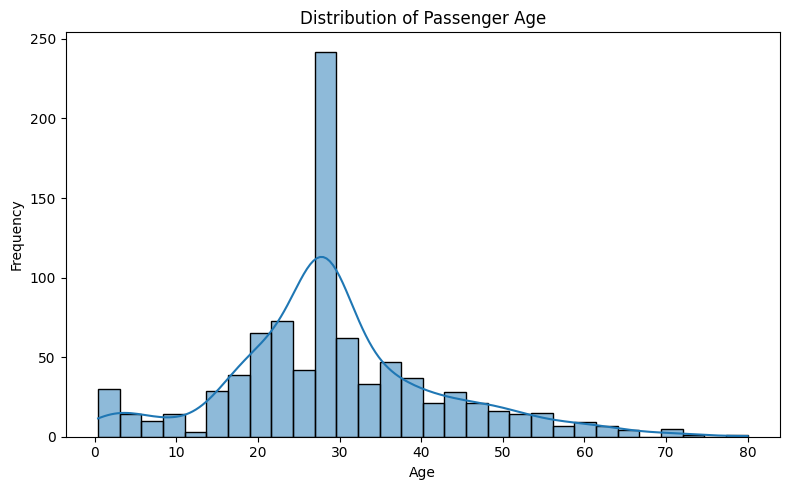

In [12]:
# ============================================================
# AGE HISTOGRAM
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="age",
    bins=30,
    kde=True
)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "charts/age_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

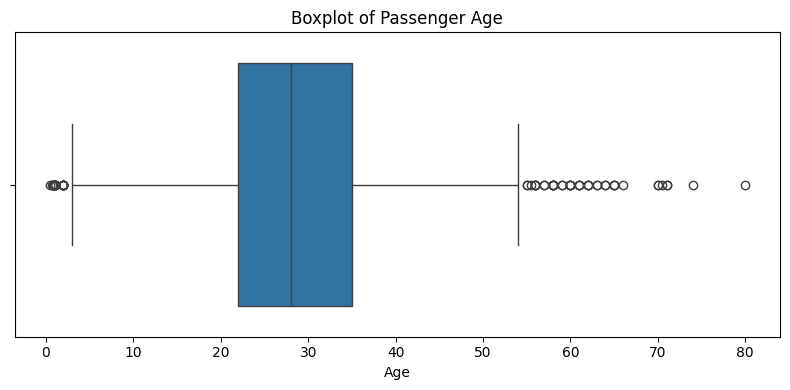

In [14]:
# ============================================================
# AGE BOXPLOT
# ============================================================

plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_clean,
    x="age"
)

plt.title("Boxplot of Passenger Age")
plt.xlabel("Age")

plt.tight_layout()

plt.savefig(
    "charts/age_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Age Distribution Interpretation

The histogram shows how passenger ages are distributed across the Titanic dataset. Most passengers are concentrated in the young-to-middle-adult age ranges, while fewer observations occur at older ages. The distribution should be interpreted together with the boxplot and IQR analysis below to identify potential outliers.

In [15]:
# ============================================================
# AGE OUTLIER DETECTION USING IQR
# ============================================================

age_q1 = df_clean["age"].quantile(0.25)
age_q3 = df_clean["age"].quantile(0.75)

age_iqr = age_q3 - age_q1

age_lower_bound = age_q1 - (1.5 * age_iqr)
age_upper_bound = age_q3 + (1.5 * age_iqr)

age_outliers = df_clean[
    (df_clean["age"] < age_lower_bound) |
    (df_clean["age"] > age_upper_bound)
]

print("Age Q1:", round(age_q1, 2))
print("Age Q3:", round(age_q3, 2))
print("Age IQR:", round(age_iqr, 2))

print(
    "Age lower bound:",
    round(age_lower_bound, 2)
)

print(
    "Age upper bound:",
    round(age_upper_bound, 2)
)

print(
    "Number of age outliers:",
    len(age_outliers)
)

Age Q1: 22.0
Age Q3: 35.0
Age IQR: 13.0
Age lower bound: 2.5
Age upper bound: 54.5
Number of age outliers: 65


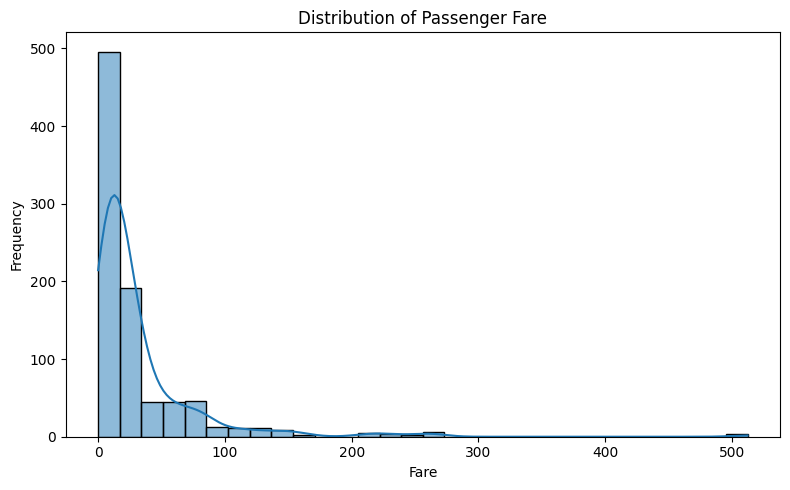

In [16]:
# ============================================================
# FARE HISTOGRAM
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="fare",
    bins=30,
    kde=True
)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "charts/fare_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

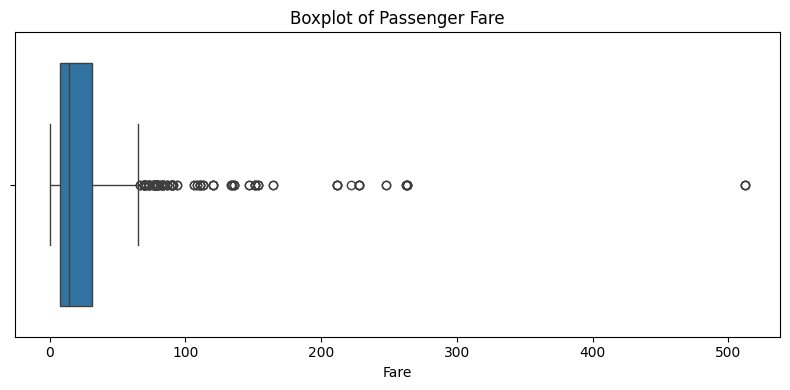

In [17]:
# ============================================================
# FARE BOXPLOT
# ============================================================

plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_clean,
    x="fare"
)

plt.title("Boxplot of Passenger Fare")
plt.xlabel("Fare")

plt.tight_layout()

plt.savefig(
    "charts/fare_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# ============================================================
# FARE OUTLIER DETECTION USING IQR
# ============================================================

fare_q1 = df_clean["fare"].quantile(0.25)
fare_q3 = df_clean["fare"].quantile(0.75)

fare_iqr = fare_q3 - fare_q1

fare_lower_bound = fare_q1 - (1.5 * fare_iqr)
fare_upper_bound = fare_q3 + (1.5 * fare_iqr)

fare_outliers = df_clean[
    (df_clean["fare"] < fare_lower_bound) |
    (df_clean["fare"] > fare_upper_bound)
]

print("Fare Q1:", round(fare_q1, 2))
print("Fare Q3:", round(fare_q3, 2))
print("Fare IQR:", round(fare_iqr, 2))

print(
    "Fare lower bound:",
    round(fare_lower_bound, 2)
)

print(
    "Fare upper bound:",
    round(fare_upper_bound, 2)
)

print(
    "Number of fare outliers:",
    len(fare_outliers)
)

Fare Q1: 7.9
Fare Q3: 31.0
Fare IQR: 23.1
Fare lower bound: -26.76
Fare upper bound: 65.66
Number of fare outliers: 114


In [19]:
# ============================================================
# FARE CENTRAL TENDENCY AND SKEWNESS
# ============================================================

fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode().iloc[0]
fare_skewness = df_clean["fare"].skew()

print("Fare Mean:", round(fare_mean, 2))
print("Fare Median:", round(fare_median, 2))
print("Fare Mode:", round(fare_mode, 2))
print("Fare Skewness:", round(fare_skewness, 2))

if fare_skewness > 0:
    print("\nInterpretation: Fare is positively (right) skewed.")
elif fare_skewness < 0:
    print("\nInterpretation: Fare is negatively (left) skewed.")
else:
    print("\nInterpretation: Fare is approximately symmetric.")

if fare_mean > fare_median:
    print(
        "The mean is greater than the median, which is "
        "consistent with a right-skewed distribution."
    )

Fare Mean: 32.1
Fare Median: 14.45
Fare Mode: 8.05
Fare Skewness: 4.8

Interpretation: Fare is positively (right) skewed.
The mean is greater than the median, which is consistent with a right-skewed distribution.


### Fare Distribution Interpretation

The fare histogram and boxplot show that passenger fares are not evenly distributed. The mean, median, mode, and calculated skewness above provide numerical evidence for the shape of the distribution. The IQR method also identifies unusually high or low fare observations as potential outliers.

In [20]:
# ============================================================
# SURVIVAL ANALYSIS
# ============================================================

overall_survival_rate = df_clean["survived"].mean() * 100

print(
    "Overall Survival Rate:",
    round(overall_survival_rate, 2),
    "%"
)

Overall Survival Rate: 38.25 %


In [21]:
# ============================================================
# SURVIVAL RATE BY SEX - BOOLEAN MASKING
# ============================================================

male_mask = df_clean["sex"] == "male"
female_mask = df_clean["sex"] == "female"

male_survival_rate = (
    df_clean[male_mask]["survived"].mean() * 100
)

female_survival_rate = (
    df_clean[female_mask]["survived"].mean() * 100
)

print(
    "Male Survival Rate:",
    round(male_survival_rate, 2),
    "%"
)

print(
    "Female Survival Rate:",
    round(female_survival_rate, 2),
    "%"
)

Male Survival Rate: 18.89 %
Female Survival Rate: 74.04 %


### Survival by Sex Interpretation

The calculated survival rates show a substantial difference between male and female passengers. The exact percentages printed above quantify this relationship. Sex therefore appears to be an important variable associated with survival in this dataset.

In [22]:
# ============================================================
# SURVIVAL RATE BY PASSENGER CLASS
# ============================================================

first_class_mask = df_clean["pclass"] == 1
second_class_mask = df_clean["pclass"] == 2
third_class_mask = df_clean["pclass"] == 3

first_class_survival = (
    df_clean[first_class_mask]["survived"].mean() * 100
)

second_class_survival = (
    df_clean[second_class_mask]["survived"].mean() * 100
)

third_class_survival = (
    df_clean[third_class_mask]["survived"].mean() * 100
)

print(
    "1st Class Survival Rate:",
    round(first_class_survival, 2),
    "%"
)

print(
    "2nd Class Survival Rate:",
    round(second_class_survival, 2),
    "%"
)

print(
    "3rd Class Survival Rate:",
    round(third_class_survival, 2),
    "%"
)

1st Class Survival Rate: 62.62 %
2nd Class Survival Rate: 47.28 %
3rd Class Survival Rate: 24.24 %


### Survival by Passenger Class Interpretation

The survival rates above show how survival differed across passenger classes. Comparing the three percentages helps determine whether passenger class was associated with survival. This relationship will also be examined together with sex in the next analysis.

In [23]:
# ============================================================
# SURVIVAL RATE BY SEX + PASSENGER CLASS
# BOOLEAN MASKING USING &
# ============================================================

female_first = (
    (df_clean["sex"] == "female") &
    (df_clean["pclass"] == 1)
)

female_second = (
    (df_clean["sex"] == "female") &
    (df_clean["pclass"] == 2)
)

female_third = (
    (df_clean["sex"] == "female") &
    (df_clean["pclass"] == 3)
)

male_first = (
    (df_clean["sex"] == "male") &
    (df_clean["pclass"] == 1)
)

male_second = (
    (df_clean["sex"] == "male") &
    (df_clean["pclass"] == 2)
)

male_third = (
    (df_clean["sex"] == "male") &
    (df_clean["pclass"] == 3)
)

print(
    "Female 1st Class:",
    round(df_clean[female_first]["survived"].mean() * 100, 2),
    "%"
)

print(
    "Female 2nd Class:",
    round(df_clean[female_second]["survived"].mean() * 100, 2),
    "%"
)

print(
    "Female 3rd Class:",
    round(df_clean[female_third]["survived"].mean() * 100, 2),
    "%"
)

print(
    "Male 1st Class:",
    round(df_clean[male_first]["survived"].mean() * 100, 2),
    "%"
)

print(
    "Male 2nd Class:",
    round(df_clean[male_second]["survived"].mean() * 100, 2),
    "%"
)

print(
    "Male 3rd Class:",
    round(df_clean[male_third]["survived"].mean() * 100, 2),
    "%"
)

Female 1st Class: 96.74 %
Female 2nd Class: 92.11 %
Female 3rd Class: 50.0 %
Male 1st Class: 36.89 %
Male 2nd Class: 15.74 %
Male 3rd Class: 13.54 %


In [24]:
# ============================================================
# BOOLEAN MASKING USING |
# Example: passengers in either 1st OR 2nd class
# ============================================================

upper_class_mask = (
    (df_clean["pclass"] == 1) |
    (df_clean["pclass"] == 2)
)

upper_class_survival = (
    df_clean[upper_class_mask]["survived"].mean() * 100
)

print(
    "Survival Rate for 1st OR 2nd Class:",
    round(upper_class_survival, 2),
    "%"
)

Survival Rate for 1st OR 2nd Class: 55.53 %


In [26]:
# ============================================================
# CORRELATION MATRIX
# EXACTLY SIX REQUIRED COLUMNS
# ============================================================

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = df_clean[
    correlation_columns
].corr()

print("Correlation Matrix:")

display(correlation_matrix)

Correlation Matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


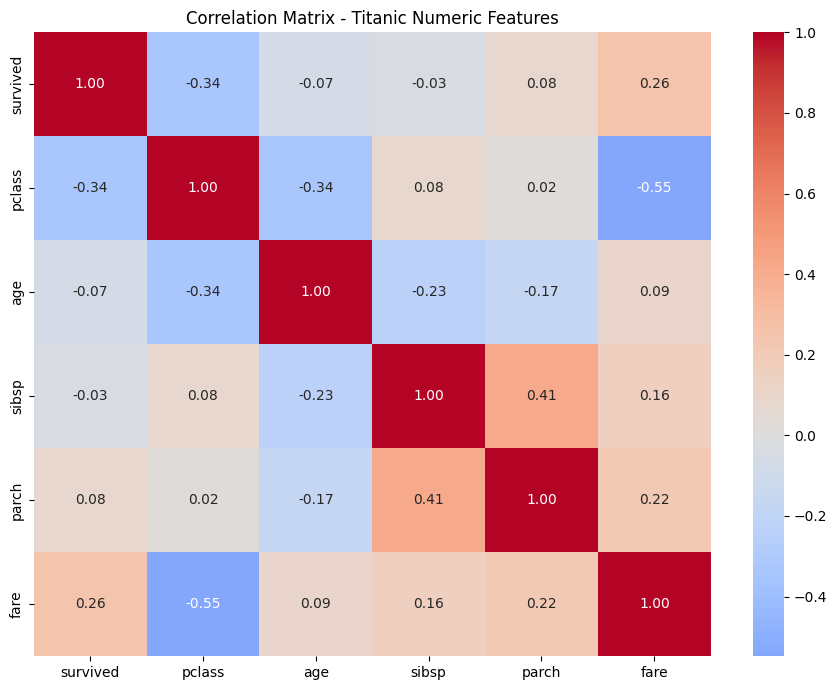

In [27]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix - Titanic Numeric Features"
)

plt.tight_layout()

plt.savefig(
    "charts/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# ============================================================
# TOP TWO ABSOLUTE OFF-DIAGONAL CORRELATIONS
# ============================================================

correlation_pairs = []

for i in range(len(correlation_columns)):
    for j in range(i + 1, len(correlation_columns)):

        column_1 = correlation_columns[i]
        column_2 = correlation_columns[j]

        correlation_value = correlation_matrix.loc[
            column_1,
            column_2
        ]

        correlation_pairs.append({
            "Variable 1": column_1,
            "Variable 2": column_2,
            "Correlation": correlation_value,
            "Absolute Correlation": abs(correlation_value)
        })

correlation_pairs_df = pd.DataFrame(correlation_pairs)

top_two_correlations = (
    correlation_pairs_df
    .sort_values(
        by="Absolute Correlation",
        ascending=False
    )
    .head(2)
)

print("Top Two Absolute Off-Diagonal Correlations:")

display(top_two_correlations)

Top Two Absolute Off-Diagonal Correlations:


,Variable 1,Variable 2,Correlation,Absolute Correlation
8,pclass,fare,-0.548193,0.548193
12,sibsp,parch,0.414542,0.414542


### Top Correlation Interpretation

The table above shows the two strongest relationships based on absolute off-diagonal correlation values. A positive correlation means that the variables tend to increase together, while a negative correlation indicates an inverse relationship. These results describe statistical association and do not by themselves establish causation.

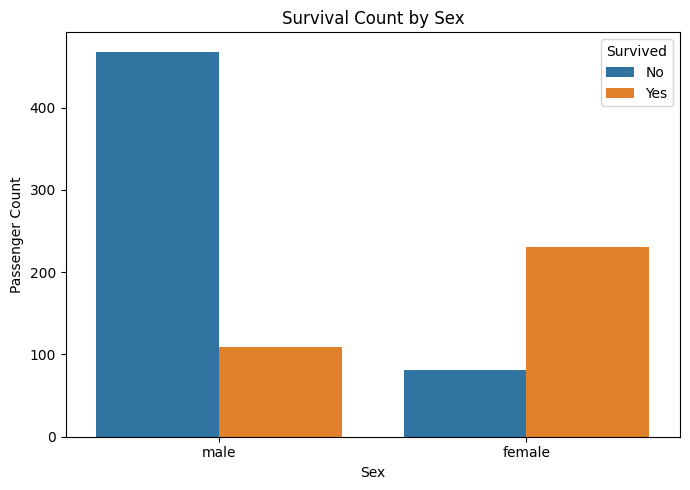

In [29]:
# ============================================================
# MULTIVARIATE CHART 1
# SEX + SURVIVAL
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="sex",
    hue="survived"
)

plt.title("Survival Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Passenger Count")
plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.tight_layout()

plt.savefig(
    "charts/survival_by_sex.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 1 — Survival by Sex

This chart compares survival outcomes between male and female passengers. The survived and non-survived groups show noticeably different patterns across sex. This supports the survival-rate calculations above and indicates that sex is associated with survival in this dataset.

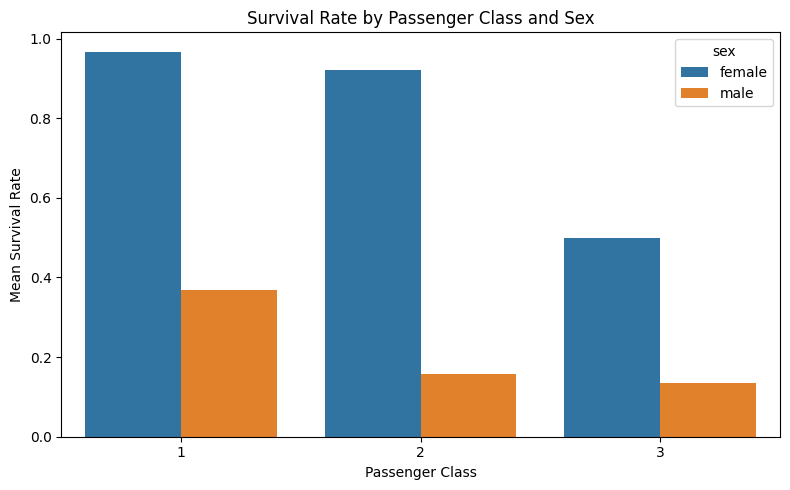

In [30]:
# ============================================================
# MULTIVARIATE CHART 2
# PASSENGER CLASS + SEX + SURVIVAL
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived",
    hue="sex",
    errorbar=None
)

plt.title(
    "Survival Rate by Passenger Class and Sex"
)

plt.xlabel("Passenger Class")
plt.ylabel("Mean Survival Rate")

plt.tight_layout()

plt.savefig(
    "charts/survival_by_class_sex.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 2 — Passenger Class, Sex and Survival

This chart compares survival rates across passenger classes while also separating passengers by sex. It makes it possible to examine whether the sex-related survival pattern remains visible within each passenger class. The visualization suggests that both passenger class and sex are relevant variables when analysing survival.

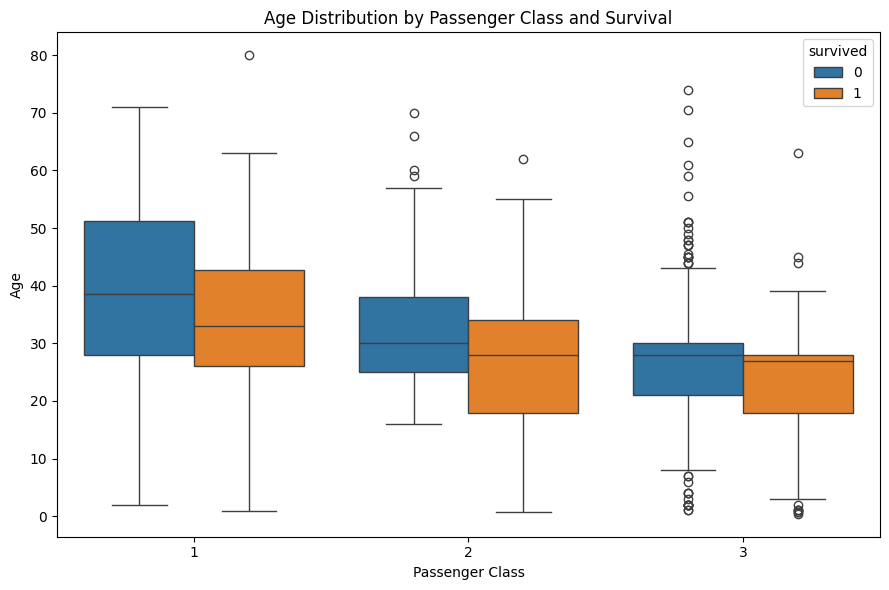

In [31]:
# ============================================================
# MULTIVARIATE CHART 3
# AGE + PASSENGER CLASS + SURVIVAL
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="pclass",
    y="age",
    hue="survived"
)

plt.title(
    "Age Distribution by Passenger Class and Survival"
)

plt.xlabel("Passenger Class")
plt.ylabel("Age")

plt.tight_layout()

plt.savefig(
    "charts/age_class_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 3 — Age, Passenger Class and Survival

The boxplot compares passenger age distributions for survived and non-survived passengers within each passenger class. It displays differences in median age, spread, and potential extreme observations across the groups. This provides a combined view of age, passenger class, and survival rather than examining age independently.

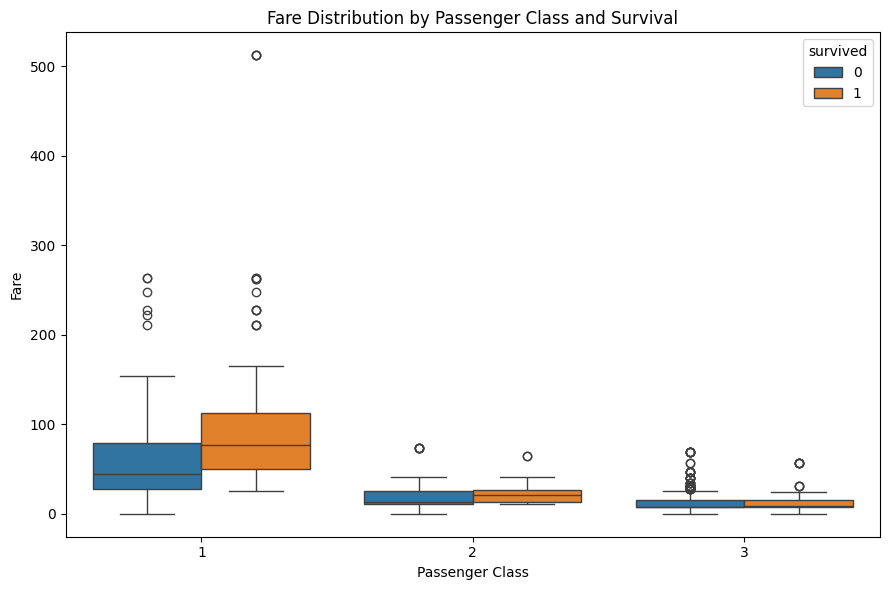

In [32]:
# ============================================================
# MULTIVARIATE CHART 4
# FARE + PASSENGER CLASS + SURVIVAL
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="pclass",
    y="fare",
    hue="survived"
)

plt.title(
    "Fare Distribution by Passenger Class and Survival"
)

plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.tight_layout()

plt.savefig(
    "charts/fare_class_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 4 — Fare, Passenger Class and Survival

This chart compares fare distributions across passenger classes while separating passengers according to survival outcome. Fare varies considerably across classes, and the survived and non-survived groups can be compared within each class. The presence of high-fare observations is consistent with the earlier fare outlier analysis.

In [33]:
# ============================================================
# STANDARDIZATION OF AGE AND FARE
# ============================================================

from sklearn.preprocessing import StandardScaler

eda_scaler = StandardScaler()

standardized_values = eda_scaler.fit_transform(
    df_clean[["age", "fare"]]
)

standardized_df = pd.DataFrame(
    standardized_values,
    columns=[
        "age_standardized",
        "fare_standardized"
    ]
)

print("Standardized Data Preview:")
display(standardized_df.head())

print("\nVerification:")

print(
    "Age Mean:",
    round(
        standardized_df["age_standardized"].mean(),
        6
    )
)

print(
    "Age Standard Deviation:",
    round(
        standardized_df["age_standardized"].std(ddof=0),
        6
    )
)

print(
    "Fare Mean:",
    round(
        standardized_df["fare_standardized"].mean(),
        6
    )
)

print(
    "Fare Standard Deviation:",
    round(
        standardized_df["fare_standardized"].std(ddof=0),
        6
    )
)

Standardized Data Preview:


,age_standardized,fare_standardized
0,-0.563674,-0.500240
1,0.669217,0.788947
2,-0.255451,-0.486650
3,0.438050,0.422861
4,0.438050,-0.484133



Verification:
Age Mean: 0.0
Age Standard Deviation: 1.0
Fare Mean: 0.0
Fare Standard Deviation: 1.0


### Standardization Interpretation

Age and fare were standardized using `StandardScaler`. After standardization, both variables have a mean approximately equal to 0 and a standard deviation approximately equal to 1. Standardization places numerical variables measured on different scales onto comparable scales.